# Tech Giants Risk & Return Analysis (EDA)

**Objective:** To extract, clean, and analyze historical stock market data for Apple (AAPL) and Microsoft (MSFT) using Python and `yfinance`.

## Phase 1: Data Gathering & Preprocessing
First, we will import the necessary libraries and fetch the last 5 years of daily market data.

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for our future charts
sns.set_theme(style="whitegrid")
print("Libraries imported successfully")

Libraries imported successfully


### Fetching the Data
We will download the historical data for AAPL and MSFT. The `yfinance` library returns a MultiIndex Pandas DataFrame containing the Open, High, Low, Close, and Volume (OHLCV) data for each day.

In [3]:
# Define our assets and the time frame
tickers = ["AAPL", "MSFT"]
period = "5y"

# Download the data
print(f"Downloading {period} of data for {tickers}...")
raw_data = yf.download(tickers, period=period)

# Display the first 5 rows to understand the structure
display(raw_data.head())

[*********************100%***********************]  2 of 2 completed


Price            Close                    High                     Low  \
Ticker            AAPL        MSFT        AAPL        MSFT        AAPL   
Date                                                                     
2021-03-08  113.334106  218.194275  117.853445  223.932438  113.188006   
2021-03-09  117.941093  224.325821  118.885870  225.861122  115.700909   
2021-03-10  116.859993  223.020828  118.993038  227.415613  116.343769   
2021-03-11  118.788498  227.540390  120.005992  229.497885  118.106704   
2021-03-12  117.882690  226.216156  118.019049  226.283332  116.061323   

Price                         Open                 Volume            
Ticker            MSFT        AAPL        MSFT       AAPL      MSFT  
Date                                                                 
2021-03-08  217.944795  117.785265  222.013318  154376600  35267400  
2021-03-09  222.301150  115.934665  223.462223  129525800  33080500  
2021-03-10  222.656191  118.525525  227.415613  111943300  29746800  
2021-03-11  224.834425  119.353417  225.458147  103026500  29907600  
2021-03-12  223.798062  117.269076  224.546517   88105100  22653700

### Data Cleaning and Isolation
For our risk and return analysis, we primarily care about the **Adjusted Close** or **Close** prices. We will isolate the 'Close' columns and check if there are any missing values (NaN) that could break our math later.

In [4]:
# Extract only the 'Close' prices
close_prices = raw_data['Close']

# Check the data types and look for missing values
print("--- Data Information ---")
close_prices.info()

print("\n--- Missing Values Count ---")
print(close_prices.isnull().sum())

# Display the clean, isolated dataset
display(close_prices.tail()) # .tail() shows the most recent days

--- Data Information ---
<class 'pandas.DataFrame'>
DatetimeIndex: 1255 entries, 2021-03-08 to 2026-03-05
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1255 non-null   float64
 1   MSFT    1255 non-null   float64
dtypes: float64(2)
memory usage: 29.4 KB

--- Missing Values Count ---
Ticker
AAPL    0
MSFT    0
dtype: int64


Ticker,AAPL,MSFT
Date,,
2026-02-27,264.179993,392.739990
2026-03-02,264.720001,398.549988
2026-03-03,263.750000,403.929993
2026-03-04,262.519989,405.200012
2026-03-05,260.290009,410.679993


## Phase 2: Exploratory Data Analysis (EDA)
Now that our data is clean, we will visualize the historical closing prices to identify long-term trends. 

Raw daily prices can be very noisy due to daily market volatility. To get a clearer picture of the actual trends, we will calculate **Moving Averages (MA)**. Specifically:
* **50-day MA:** Represents the short-to-medium-term trend.
* **200-day MA:** Represents the long-term trend.

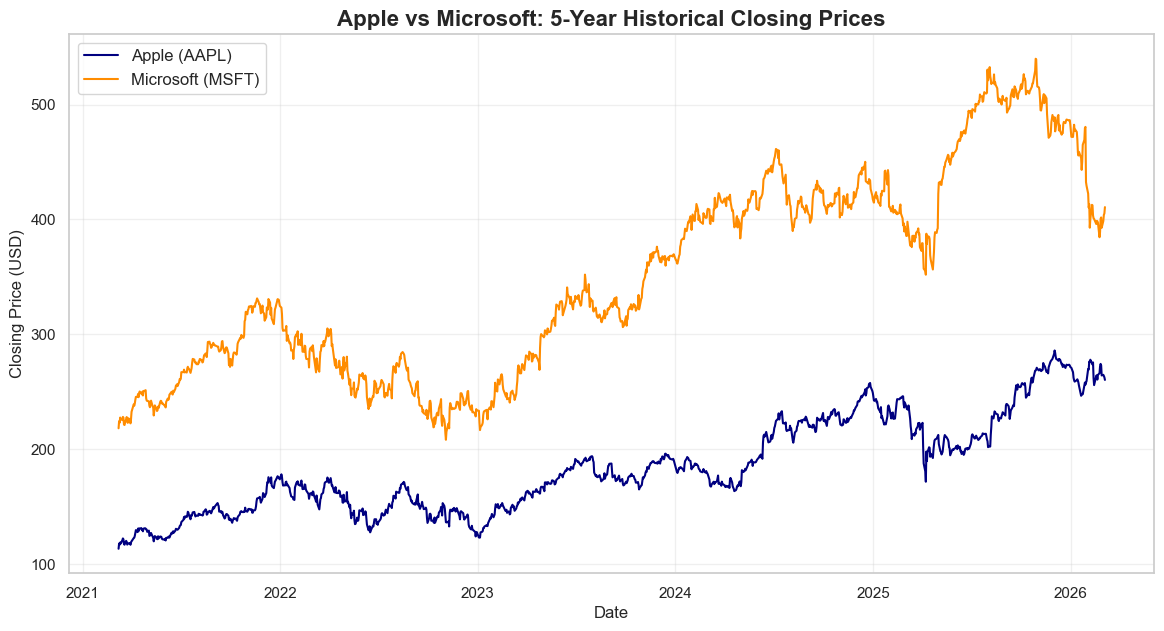

In [5]:
# Set the figure size for a nice, wide chart
plt.figure(figsize=(14, 7))

# Plot the closing prices for both companies
plt.plot(close_prices.index, close_prices['AAPL'], label='Apple (AAPL)', color='navy', linewidth=1.5)
plt.plot(close_prices.index, close_prices['MSFT'], label='Microsoft (MSFT)', color='darkorange', linewidth=1.5)

# Add titles and labels
plt.title('Apple vs Microsoft: 5-Year Historical Closing Prices', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Closing Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, alpha=0.3)

# Show the plot
plt.show()

### Moving Averages (Smoothing the Noise)
Let's zoom in on Apple and calculate its 50-day and 200-day Moving Averages. Financial analysts look for moments when a short-term MA crosses a long-term MA (like a "Golden Cross" or "Death Cross") to identify major shifts in momentum.

We use moving averages to reveal the true underlaying trends, smoothing out the market noise.
[Moving Average Crossover - tradingpedia.com](https://www.tradingpedia.com/forex-academy/moving-average-crossover/)

**Why using 50-day and 200-day?** These are industry standards used by professional traders and algorithms. 50-day is aproximately 2.5 months and reacts relatively quickly to price changes. On the other hand, 200-day represents the tren of roughly the last year (252 trading days aproximately), and shows the big-picture macroeconomic trend.

In [6]:
# Calculate the Moving Averages for Apple
apple_ma50 = close_prices['AAPL'].rolling(window=50).mean()
apple_ma200 = close_prices['AAPL'].rolling(window=200).mean()

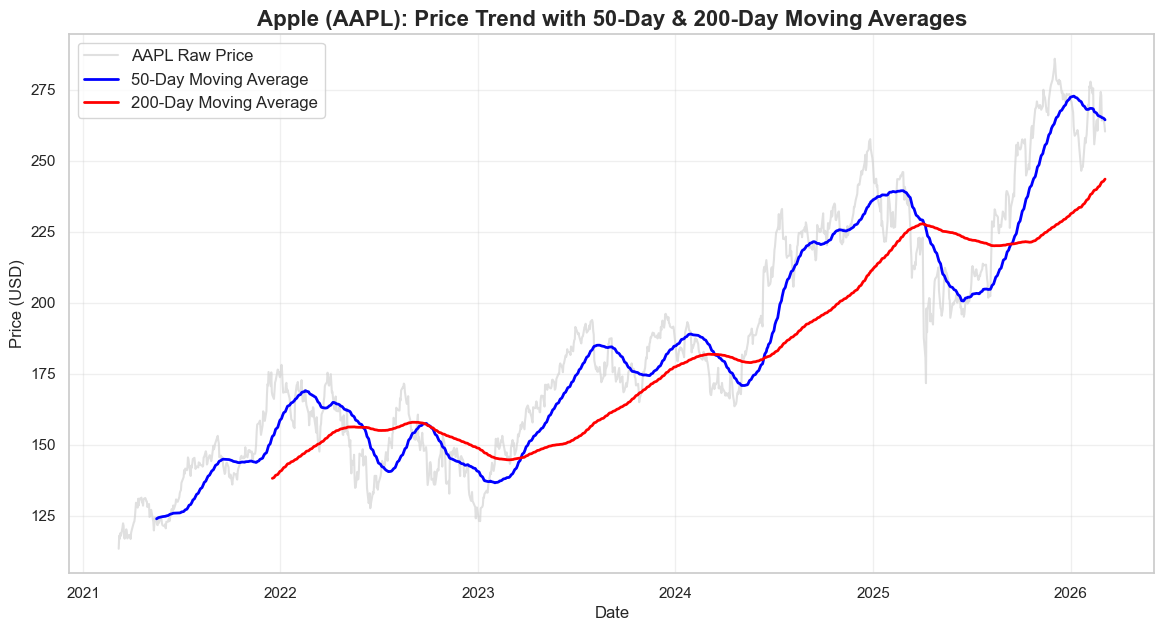

In [ ]:
# Create the plot
plt.figure(figsize=(14, 7))

# Plot the raw price and the two moving averages
plt.plot(close_prices.index, close_prices['AAPL'], label='AAPL Raw Price', color='lightgray', alpha=0.7)
plt.plot(close_prices.index, apple_ma50, label='50-Day Moving Average', color='blue', linewidth=2)
plt.plot(close_prices.index, apple_ma200, label='200-Day Moving Average', color='red', linewidth=2)

# Formatting
plt.title('Apple (AAPL): Price Trend with 50-Day & 200-Day Moving Averages', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

### Visual Inspection (2024 - Present)
Before writing an algorithm to detect Golden and Death crosses automatically, let's zoom in on Apple's chart from 2024 onwards to see if we can spot any crossovers with the naked eye.

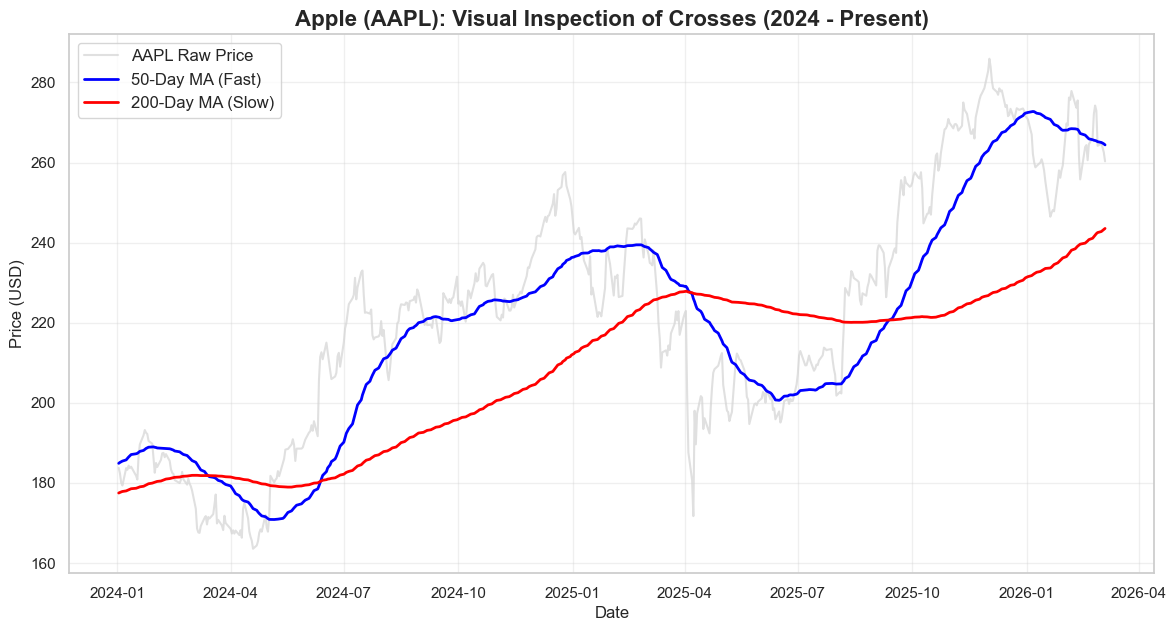

In [8]:
# 1. Define our starting date for the zoom
start_date = '2024-01-01'

# 2. Slice our existing 5-year data to only keep rows from 2024 onwards
# Pandas' .loc[] allows us to filter by date easily
aapl_price_zoomed = close_prices['AAPL'].loc[start_date:]
aapl_ma50_zoomed = apple_ma50.loc[start_date:]
aapl_ma200_zoomed = apple_ma200.loc[start_date:]

# 3. Create the zoomed-in plot
plt.figure(figsize=(14, 7))

# Plot the raw price and the two moving averages
plt.plot(aapl_price_zoomed.index, aapl_price_zoomed, label='AAPL Raw Price', color='lightgray', alpha=0.7)
plt.plot(aapl_ma50_zoomed.index, aapl_ma50_zoomed, label='50-Day MA (Fast)', color='blue', linewidth=2)
plt.plot(aapl_ma200_zoomed.index, aapl_ma200_zoomed, label='200-Day MA (Slow)', color='red', linewidth=2)

# Formatting
plt.title('Apple (AAPL): Visual Inspection of Crosses (2024 - Present)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

**Crossover**: When a short-term average (blue) crosses through a long term average (red) as shown in the graph above.

**Golden Cross**: short-term line crosses **above** the long-term line.

**Death Cross**: short-term line crosses **below** the long-term line.

Looking at this data we can find multiple crossovers:
- **March 2024**: Death Cross -> Closing price ~= 180
- **June 2024**: Golden Cross -> Closing price ~= 180
- **April 2025**: Death Cross -> Closing price ~= 225
- **September 2025**: Golden Cross ->  -> Closing price ~= 220

### Algorithmic Cross Detection
Visual inspection is great, but to scale our analysis, we need an algorithm. 
We will create a binary signal: 
* `1` when the 50-Day MA is strictly greater than the 200-Day MA.
* `0` when it is less than or equal to the 200-Day MA.

By calculating the day-to-day difference of this signal, a `1` will represent a Golden Cross (0 to 1), and a `-1` will represent a Death Cross (1 to 0).

In [9]:
# 1. Combine our zoomed data into a single DataFrame
aapl_trends = pd.DataFrame({
    'Price': aapl_price_zoomed,
    'MA50': aapl_ma50_zoomed,
    'MA200': aapl_ma200_zoomed
})

# 2. Create the Signal column (1 if MA50 > MA200, else 0)
aapl_trends['Signal'] = (aapl_trends['MA50'] > aapl_trends['MA200']).astype(int)

# 3. Calculate the daily difference to find the exact crossover days
aapl_trends['Cross'] = aapl_trends['Signal'].diff()

# 4. Extract the exact dates
golden_crosses = aapl_trends[aapl_trends['Cross'] == 1.0]
death_crosses = aapl_trends[aapl_trends['Cross'] == -1.0]

print("--- Golden Crosses (Buy Signals) ---")
display(golden_crosses[['Price', 'MA50', 'MA200']])

print("\n--- Death Crosses (Sell Signals) ---")
display(death_crosses[['Price', 'MA50', 'MA200']])

--- Golden Crosses (Buy Signals) ---


,Price,MA50,MA200
Date,,,
2024-06-13,212.595764,180.964457,180.478417
2025-09-15,236.249695,221.047639,220.678903



--- Death Crosses (Sell Signals) ---


,Price,MA50,MA200
Date,,,
2024-03-14,171.439758,181.739930,181.795276
2025-04-07,180.672562,227.152678,227.481563
